In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

5 ASSUMPTIONS of Linear Regression (Your Understanding ✓)
1. LINEARITY ✓
Your scatter plot = LOOKS LINEAR! (dots follow straight line, not curve)
2. INDEPENDENCE ✓
"One row don't affect second row" = CORRECT!

House 1 price doesn't affect House 2 price.
3. HOMOSCEDASTICITY ✓
"Error should be same size for small and big"

Small price (4 rooms): error ±$2K ✓
Big price (8 rooms): error ±$15K ✗ (bigger errors for bigger prices = BAD)

Check: Plot residuals vs predicted - should be constant width, not funnel.
4. NORMALITY ✓
"Error should be normal distributed (bell curve), not linear"

Most errors small (±$5K)
Few errors big (±$20K)

= Bell curve ✓

Check: Histogram of residuals - bell shape?
5. NO MULTICOLLINEARITY ✓
"Features should not be related to each other"

Feature: rooms
Feature: age
These shouldn't be correlated (room count doesn't predict age)

Check: Correlation matrix - all values < 0.7? ✓

In [38]:
df = pd.read_csv("/Users/subhashmothukurigmail.com/Projects/ML_stuff/data/ameshousing.csv")

In [ ]:
print("=" * 60)
print("Data Overview")
print("=" * 60)
print(f"Shape:  {df.shape}")

Data Overview
Shape:  (506, 15)


In [43]:
print(f"\nFirst 5 Rows: ")
print(df.head())


First 5 Rows: 
   Unnamed: 0     crim    zn  indus  chas  ...  tax  ptratio       b  lstat  medv
0           0  0.00632  18.0   2.31     0  ...  296     15.3  396.90   4.98  24.0
1           1  0.02731   0.0   7.07     0  ...  242     17.8  396.90   9.14  21.6
2           2  0.02729   0.0   7.07     0  ...  242     17.8  392.83   4.03  34.7
3           3  0.03237   0.0   2.18     0  ...  222     18.7  394.63   2.94  33.4
4           4  0.06905   0.0   2.18     0  ...  222     18.7  396.90   5.33  36.2

[5 rows x 15 columns]


In [44]:
print(f"\nData types.")
print(df.dtypes)


Data types.
Unnamed: 0      int64
crim          float64
zn            float64
indus         float64
chas            int64
nox           float64
rm            float64
age           float64
dis           float64
rad             int64
tax             int64
ptratio       float64
b             float64
lstat         float64
medv          float64
dtype: object


In [46]:
print(f"\n Missing Values: ")
print(df.isnull().sum())


 Missing Values: 
Unnamed: 0    0
crim          0
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64


In [52]:
print("=" * 60)
print("Check the Price Skiwed")
print("=" * 60)

df['price'] = df['medv']
print(f"\nCount: {df['price'].count()}")
print(f"\nMean: {df['price'].mean():,.0f}")
print(f"\nMedian: {df['price'].median():,.0f}")
print(f"Std: {df['price'].std():,.0f}")
print(f"Minimum : {df['price'].min():,.0f}")
print(f"Max: ${df['price'].max():,.0f}")

print(f"\nSkewness: {df['price'].skew():.2f}")
if df['price'].skew() > 0.5:
    print("→ RIGHT-SKEWED (expensive houses pull up average)")
elif df['price'].skew() < -0.5:
    print("→ LEFT-SKEWED (cheap houses pull down average)")
else:
    print("→ FAIRLY NORMAL")

Check the Price Skiwed

Count: 506

Mean: 23

Median: 21
Std: 9
Minimum : 5
Max: $50

Skewness: 1.11
→ RIGHT-SKEWED (expensive houses pull up average)


In [53]:
#This is Right Skewed lets make it right skewed to log transfromation:

#Log Tranformation

In [59]:
df['price'] = np.log1p(df['price'])

print(f"\nCount: {df['price'].count()}")
print(f"\nMean: {df['price'].mean():,.4f}")
print(f"\nMedian: {df['price'].median():,.4f}")
print(f"Std: {df['price'].std():,.4f}")
print(f"Minimum : {df['price'].min():,.4f}")
print(f"Max: ${df['price'].max():,.4f}")
print(f"\nSkewness: {df['price'].skew():.2f}")
if df['price'].skew() > 0.5:
    print("→ RIGHT-SKEWED (expensive houses pull up average)")
elif df['price'].skew() < -0.5:
    print("→ LEFT-SKEWED (cheap houses pull down average)")
else:
    print("→ FAIRLY NORMAL")



Count: 506

Mean: 0.4877

Median: 0.4894
Std: 0.0137
Minimum : 0.4281
Max: $0.5127

Skewness: -0.99
→ LEFT-SKEWED (cheap houses pull down average)



Original size: 506
After removing (>$45K): 484
Removed: 22 expensive houses

Original price skewness: 1.11
After removing outliers: 0.55


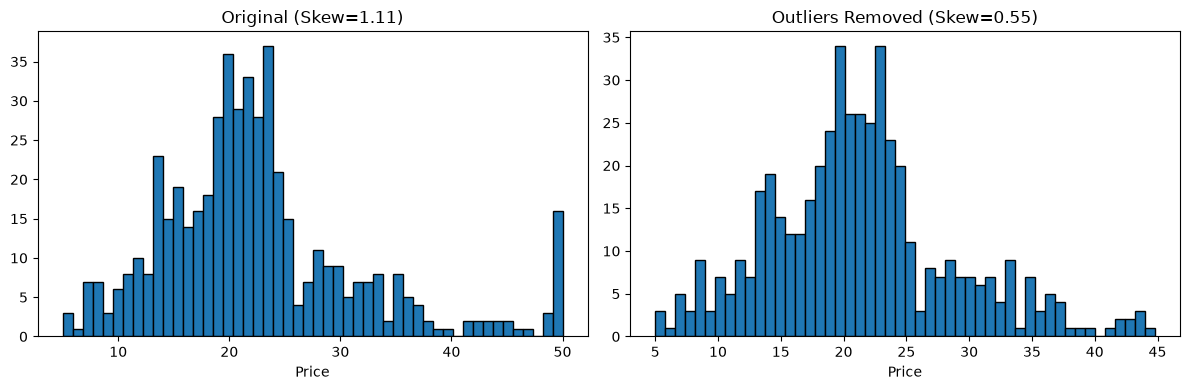


✓ Removing outliers IMPROVED skewness!


In [61]:
df_clean = df[df['medv']<= 45]
print(f"\nOriginal size: {len(df)}")
print(f"After removing (>$45K): {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} expensive houses")

print(f"\nOriginal price skewness: {df['medv'].skew():.2f}")
print(f"After removing outliers: {df_clean['medv'].skew():.2f}")

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['medv'], bins=50, edgecolor='black')
plt.title(f'Original (Skew={df["medv"].skew():.2f})')
plt.xlabel('Price')

plt.subplot(1, 2, 2)
plt.hist(df_clean['medv'], bins=50, edgecolor='black')
plt.title(f'Outliers Removed (Skew={df_clean["medv"].skew():.2f})')
plt.xlabel('Price')

plt.tight_layout()
plt.show()

if abs(df_clean['medv'].skew()) < abs(df['medv'].skew()):
    print("\n✓ Removing outliers IMPROVED skewness!")
else:
    print("\n✗ Didn't help much")

In [66]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(['Unnamed: 0', 'medv', 'price'], axis = 1)
y = df_clean['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape : {X_test.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test SHape : {y_test.shape}")

print(f"\n Feature in X : {X.columns.tolist()}")



X_train Shape : (387, 13)
X_test Shape : (97, 13)
y_train Shape : (387,)
y_test SHape : (97,)

 Feature in X : ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']


In [69]:
#Scale the Features : StandardScaler 
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

# 5. Verify (print first row before/after)
print("Before scaling:")
print(X_train.iloc[0])
print("\nAfter scaling:")
print(X_train_scaled[0])

# 6. Check shapes (should be same)
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Before scaling:
crim        13.9134
zn           0.0000
indus       18.1000
chas         0.0000
nox          0.7130
rm           6.2080
age         95.0000
dis          2.2222
rad         24.0000
tax        666.0000
ptratio     20.2000
b          100.6300
lstat       15.1700
Name: 434, dtype: float64

After scaling:
[ 1.13613611 -0.48525214  1.03357638 -0.26836945  1.32334532 -0.02511035
  0.93314008 -0.75742258  1.6388153   1.53804954  0.80004267 -2.52108186
  0.30539056]

X_train_scaled shape: (387, 13)
X_test_scaled shape: (97, 13)


In [ ]:
from sklearn.linear_model import LinearRegression
lin_Reg = LinearRegression()

lin_Reg.fit(X_train_scaled, y_train)

y_pred = lin_Reg.predict(X_test_scaled)

from sklearn.linear_model import Randam



In [74]:
#Evaluation of model Performance with r2 and mean_squared_error

from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
m2error = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(m2error)


print(f"MSE: {m2error:.4f} in dollars")
print(f"R2 Score: {r2:.4f}")

print(f"RMSE: {rmse:.2f} (in $10K)")
print(f"RMSE: ${rmse * 1000:.0f} (in dollars)")

MSE: 11.8591 in dollars
R2 Score: 0.7856
RMSE: 3.44 (in $10K)
RMSE: $3444 (in dollars)


In [75]:
avg_price = y_test.mean()
error_pct = (rmse / avg_price) * 100

print(f"Average house price: ${avg_price:.2f} (in $10K)")
print(f"Average house price: ${avg_price * 1000:.0f} (in dollars)")
print(f"\nError %: {error_pct:.1f}%")

# Interpretation
print("\n" + "="*60)
print("DECISION: Is This Good?")
print("="*60)
if error_pct < 10:
    print("✓ EXCELLENT (error < 10%)")
elif error_pct < 15:
    print("✓ VERY GOOD (error < 15%)")
elif error_pct < 20:
    print("✓ GOOD (error < 20%)")
else:
    print("⚠️ ACCEPTABLE (error > 20%)")

print(f"\nR² = {r2:.4f} (Explains {r2*100:.1f}% of variation)")
print(f"RMSE = ${rmse*1000:.0f}")

Average house price: $21.15 (in $10K)
Average house price: $21148 (in dollars)

Error %: 16.3%

DECISION: Is This Good?
✓ GOOD (error < 20%)

R² = 0.7856 (Explains 78.6% of variation)
RMSE = $3444


In [78]:
"""Now if i want to improve the performance of this model to 78 to more then i should use the
1) adding the more revlenet features,
2) remove irrevlent fetuers, 3)
use polynomical features 
4) use Ridge or lasso regression.


or

Path 2: Switch to Better Algorithm
Models:

Random Forest
Gradient Boosting (XGBoost)
Neural Networks

Pros: Can achieve higher R² (0.85-0.95)

Cons: Slower, harder to interpret, need more data """



#Feature Engineering .. 

#age incerease cost decrease dramatically
df_clean['age_squared']= df_clean['age']** 2

#room increases cost increases dramatically
df_clean['rm_squared'] = df_clean['rm']** 2

#room time status of neighbornhoods
df_clean['rm_lstat_interaction'] = df_clean['rm']* df_clean['lstat']

#tax while tell how many rooms they get based on income
df_clean['tax_per_room'] = df_clean['tax'] / df_clean['rm']


#distance increase prices decrease non_linearly or dramatically.
df_clean['dis_squared']= df_clean['dis']** 2

#step 2: check the correlation ship between the Price.
print("\nNew Features correlation with price:")
print("="*60)

new_features = ['age_squared', 'rm_squared', 'rm_lstat_interaction', 
                'tax_per_room', 'dis_squared']

good_new_features = []  # List to store GOOD features

for feature in new_features:
    corr = df_clean[feature].corr(df_clean['medv'])
    print(f"{feature:25s}: {corr:7.3f}", end="")
    
    if abs(corr) > 0.3:  # Keep if correlation > 0.3
        print(" ✓ KEEP")
        good_new_features.append(feature)
    else:
        print(" ✗ DROP")

# Step 3: Show which features to keep
print("\n" + "="*60)
print(f"Good features to add: {good_new_features}")








New Features correlation with price:
age_squared              :  -0.533 ✓ KEEP
rm_squared               :   0.671 ✓ KEEP
rm_lstat_interaction     :  -0.762 ✓ KEEP
tax_per_room             :  -0.630 ✓ KEEP
dis_squared              :   0.314 ✓ KEEP

Good features to add: ['age_squared', 'rm_squared', 'rm_lstat_interaction', 'tax_per_room', 'dis_squared']


In [83]:
df_clean.columns.tolist()

from sklearn.model_selection import train_test_split

X = df_clean.drop(['Unnamed: 0', 'medv', 'price'], axis = 1)
y = df_clean['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape : {X_test.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test SHape : {y_test.shape}")

print(f"\n Feature in X : {X.columns.tolist()}")


X_train Shape : (387, 18)
X_test Shape : (97, 18)
y_train Shape : (387,)
y_test SHape : (97,)

 Feature in X : ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'age_squared', 'rm_squared', 'rm_lstat_interaction', 'tax_per_room', 'dis_squared']


In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Make sure you have X_train, X_test, y_train, y_test from split

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Step 1: Scale
scaler_new = StandardScaler()
X_train_scaled = scaler_new.fit_transform(X_train)
X_test_scaled = scaler_new.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")

# Step 2: Train
model_new = LinearRegression()
model_new.fit(X_train_scaled, y_train)

# Step 3: Predict
y_pred_new = model_new.predict(X_test_scaled)

# Step 4: Evaluate
r2_new = r2_score(y_test, y_pred_new)
mse_new = mean_squared_error(y_test, y_pred_new)
rmse_new = np.sqrt(mse_new)

# Compare
print("\n" + "="*60)
print("OLD vs NEW MODEL")
print("="*60)

print("\nOLD (13 features):")
print(f"  R² = 0.7856")
print(f"  RMSE = $3,444")

print("\nNEW (18 features):")
print(f"  R² = {r2_new:.4f}")
print(f"  RMSE = ${rmse_new*1000:.0f}")

diff_r2 = (r2_new - 0.7856) * 100
print(f"\nImprovement: {diff_r2:+.2f}%")

if r2_new > 0.7856:
    print("✓ IMPROVED!")
else:
    print("✗ WORSE (overfitting)")


X_train shape: (387, 18)
y_train shape: (387,)
X_train_scaled shape: (387, 18)

OLD vs NEW MODEL

OLD (13 features):
  R² = 0.7856
  RMSE = $3,444

NEW (18 features):
  R² = 0.8630
  RMSE = $2752

Improvement: +7.74%
✓ IMPROVED!


In [87]:
from sklearn.linear_model import Ridge

alphas  = [0.1, 1.0, 10.0, 100.0]

best_r2 = 0
best_aplha = 0

for alpha in alphas: 
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_train_scaled, y_train)

    y_pred = ridge.predict(X_test_scaled)
    r2= r2_score(y_test, y_pred)


    print(f"Alpha= {alpha : 6.1f}: R2 = {r2: .4f}")

    if r2 > best_r2:
        best_r2 = r2
        best_aplha = alpha
print(f"\nBest: Alpha= {best_aplha}, R2 = {best_r2:.4f}")



Alpha=    0.1: R2 =  0.8642
Alpha=    1.0: R2 =  0.8649
Alpha=   10.0: R2 =  0.8357
Alpha=  100.0: R2 =  0.7880

Best: Alpha= 1.0, R2 = 0.8649


In [95]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators= 100, max_depth= 15, random_state= 42, n_jobs= 1)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)


r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)


print(f"R2 for Ridge = {best_r2:.4f} and R2 for Random Forest Regression is = {r2_rf:.4f}")
if r2_rf > best_r2:
    print(f"Improment : {(r2_rf - best_r2)*100:+.2f}%")

print(f"RMSE is : {rmse_rf}")

R2 for Ridge = 0.8649 and R2 for Random Forest Regression is = 0.8878
Improment : +2.29%
RMSE is : 2.4914960624128106


In [97]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Train with GridSearch best parameters
rf_tuned = RandomForestRegressor(
    max_depth=15,
    n_estimators=200,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_scaled, y_train)

# Test on actual test set
y_pred_tuned = rf_tuned.predict(X_test_scaled)

r2_tuned = r2_score(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("="*60)
print("COMPARISON: Original vs Tuned")
print("="*60)

print("\nOriginal Random Forest:")
print(f"  R² = 0.8878")
print(f"  RMSE = $2,491")

print("\nTuned Random Forest:")
print(f"  R² = {r2_tuned:.4f}")
print(f"  RMSE = ${rmse_tuned*1000:.0f}")

diff = (r2_tuned - 0.8878) * 100
print(f"\nDifference: {diff:+.2f}%")

if r2_tuned > 0.8878:
    print("✓ TUNED IS BETTER - USE IT")
else:
    print("✗ ORIGINAL IS BETTER - KEEP ORIGINAL")

COMPARISON: Original vs Tuned

Original Random Forest:
  R² = 0.8878
  RMSE = $2,491

Tuned Random Forest:
  R² = 0.8867
  RMSE = $2503

Difference: -0.11%
✗ ORIGINAL IS BETTER - KEEP ORIGINAL
